# **Predicción de consumo con Prophet**

## **Carga de datos**

In [ ]:

import pandas as pd

file_path = r"C:/Users/alexa/OneDrive/Documentos/Curso5/Proyectos4/consumo_ts_parte_0.csv"

df = pd.read_csv(file_path)  

df['timestamp'] = pd.to_datetime(df['timestamp'])

df.head()
    

,casa_id,timestamp,consumo_kwh,coste_euros
0,1,2017-05-31 01:00:00,0.049,0.007286
1,1,2017-05-31 02:00:00,0.112,0.015633
2,1,2017-05-31 03:00:00,0.058,0.007817
3,1,2017-05-31 04:00:00,0.097,0.014200
4,1,2017-05-31 05:00:00,0.078,0.012555


## **Preprocesamiento de datos**

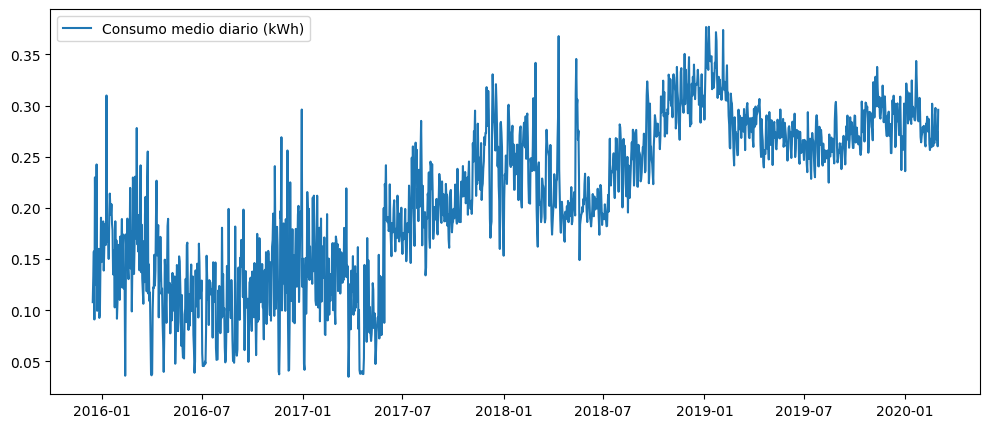

In [ ]:

df_daily = df.groupby(df['timestamp'].dt.date).agg({'consumo_kwh': 'mean'}).reset_index()

df_daily.columns = ['ds', 'y']

df_daily['ds'] = pd.to_datetime(df_daily['ds'])

import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(df_daily['ds'], df_daily['y'], label='Consumo medio diario (kWh)')
plt.legend()
plt.show()
    

## **Modelo simple con Prophet**

c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
10:16:13 - cmdstanpy - INFO - Chain [1] start processing
10:16:14 - cmdstanpy - INFO - Chain [1] done processing


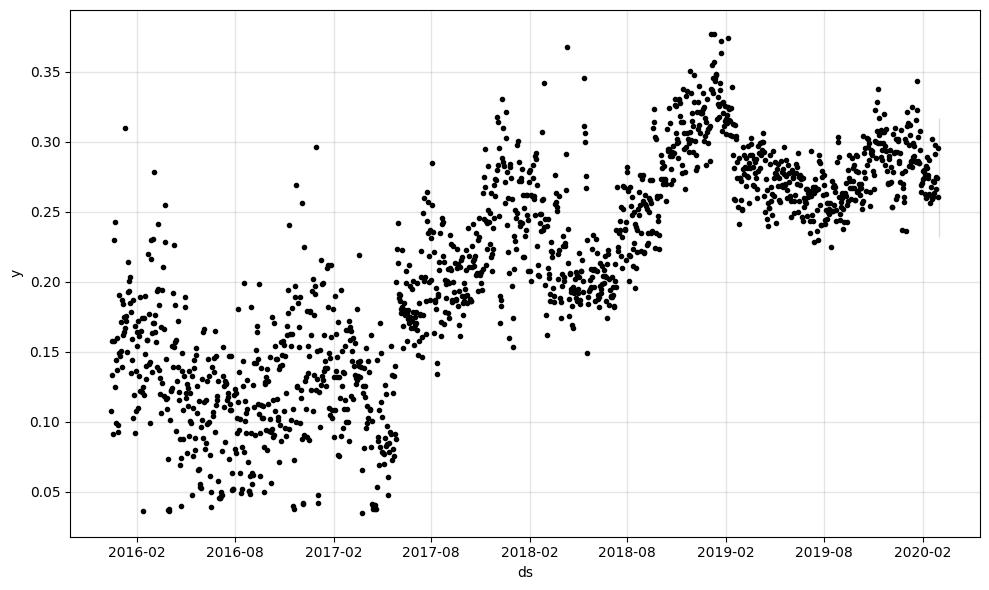

In [ ]:

from prophet import Prophet

model_simple = Prophet()
model_simple.fit(df_daily)

import pandas as pd
from datetime import timedelta

future = pd.DataFrame({'ds': [df_daily['ds'].max() + timedelta(days=1)]})
forecast = model_simple.predict(future)

fig = model_simple.plot(forecast)
plt.show()
    

## **Evaluación del Modelo Simple con Métricas y Visualización**

Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
  0%|          | 0/39 [00:00<?, ?it/s]10:16:22 - cmdstanpy - INFO - Chain [1] start processing
10:16:22 - cmdstanpy - INFO - Chain [1] done processing
  3%|▎         | 1/39 [00:00<00:06,  5.88it/s]10:16:22 - cmdstanpy - INFO - Chain [1] start processing
10:16:23 - cmdstanpy - INFO - Chain [1] done processing
  5%|▌         | 2/39 [00:00<00:08,  4.33it/s]10:16:23 - cmdstanpy - INFO - Chain [1] start processing
10:16:23 - cmdstanpy - INFO - Chain [1] done processing
  8%|▊         | 3/39 [00:00<00:06,  5.24it/s]10:16:23 - cmdstanpy - INFO - Chain [1] start processing
10:16:23 - cmdstanpy - INFO - Chain [1] done processing
 10%|█         | 4/39 [00:00<00:06,  5.61it/s]10:16:23 - cmdstanpy - INFO - Chain [1] start processing
10:16:23 - cmdstanpy - INFO - Chain [1] done processing
 13%|█▎        | 5/39 [00:00<00:05,  5.84it/s]10:16:23 - cmdstanpy - INFO - Chain [1] start processing
10:16:

Métricas del modelo simple:
            mae       mse      rmse      mape
count  7.000000  7.000000  7.000000  7.000000
mean   0.027065  0.001183  0.033688  0.148008
std    0.005946  0.000505  0.007470  0.042736
min    0.018005  0.000481  0.021935  0.081596
25%    0.023723  0.000897  0.029952  0.124478
50%    0.026548  0.001081  0.032883  0.137857
75%    0.030850  0.001443  0.037988  0.183328
max    0.035761  0.002036  0.045117  0.200995
Predicción para el 2020-03-02 00:00:00 - Consumo estimado: 0.28 kWh


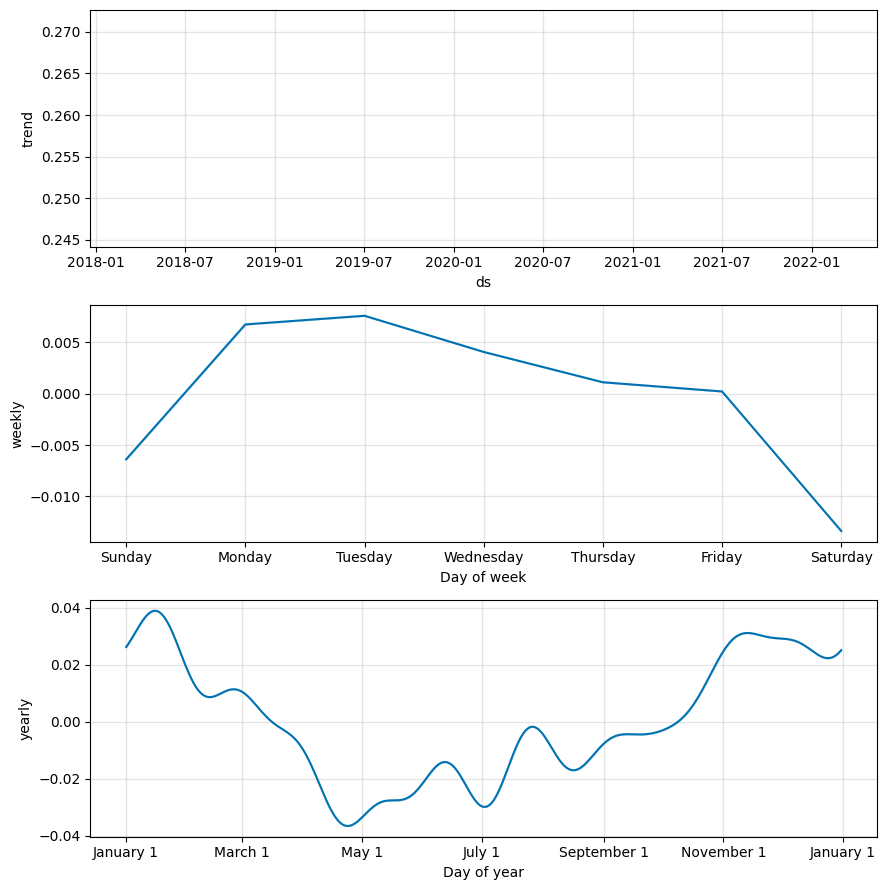

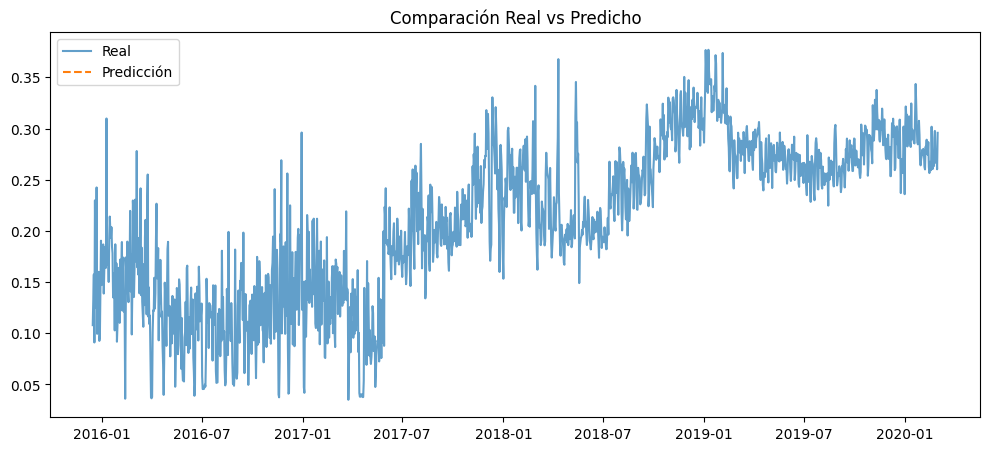

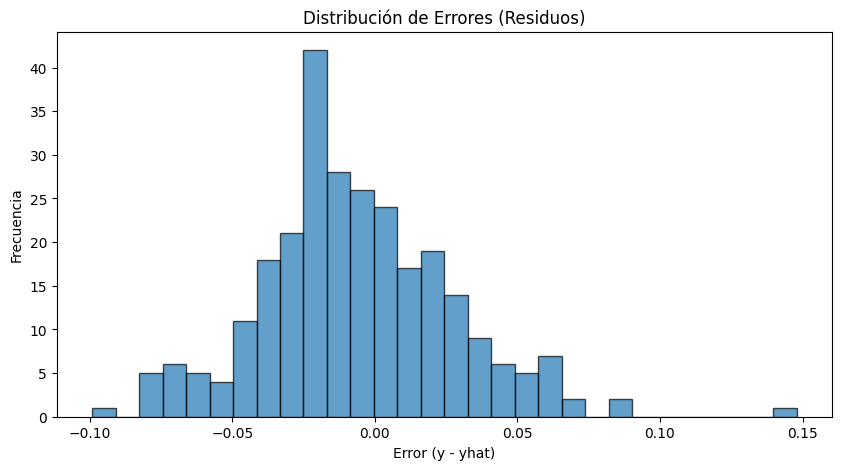

In [ ]:

from prophet.diagnostics import cross_validation, performance_metrics
import numpy as np

df_cv = cross_validation(model_simple, initial='365 days', period='30 days', horizon='7 days')
df_p = performance_metrics(df_cv)

# Mostrar métricas de error
print("Métricas del modelo simple:")
print(df_p[['mae', 'mse', 'rmse', 'mape']].describe())

# Obtener predicción específica para el día siguiente
predicted_value = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].iloc[0]
print(f"Predicción para el {predicted_value['ds']} - Consumo estimado: {predicted_value['yhat']:.2f} kWh")

# Gráfico de componentes (tendencias y estacionalidad)
model_simple.plot_components(forecast)
plt.show()

# Comparación de valores reales vs predichos
plt.figure(figsize=(12,5))
plt.plot(df_daily['ds'], df_daily['y'], label="Real", alpha=0.7)
plt.plot(forecast['ds'], forecast['yhat'], label="Predicción", linestyle="dashed")
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], alpha=0.2)
plt.legend()
plt.title("Comparación Real vs Predicho")
plt.show()

# Gráfico de residuos (diferencias entre valores reales y predichos)
residuals = df_cv['y'] - df_cv['yhat']
plt.figure(figsize=(10,5))
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
plt.title("Distribución de Errores (Residuos)")
plt.xlabel("Error (y - yhat)")
plt.ylabel("Frecuencia")
plt.show()
